# Additional analysis for revision

In [66]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

model_path = os.getenv('MODEL')

data_path = os.getenv('TRAINING_DATA')
train = pd.read_csv(data_path)
train = train.dropna()
train = train.drop(columns = 'Studio')
train.shape

(3599, 19)

In [67]:
import bagging
from xgboost import Booster
labelcols = {
    'lower': 'esrd_lower',
    'upper': 'esrd_upper'
}
best_params = {'objective': 'survival:aft',
               'eval_metric': 'aft-nloglik',
               'aft_loss_distribution': 'extreme',
               'aft_loss_distribution_scale': 0.1,
               'tree_method': 'hist',
               'learning_rate': 0.01,
               'max_depth': [8,10],
               'booster': 'gbtree',
               'subsample': 1.0,
               'min_child_weight': 1.0,
               'colsample_bynode': 1.0,
               'n_models': 50,
               'subset_fraction': 1.0}
model = bagging.BaggingXGBRegressor(params = best_params, 
                                    labelcols=labelcols, 
                                    verbose = True)
model._BaggingXGBRegressor__models = []
for m_path in os.listdir(model_path):
    m = Booster()
    m.load_model(f'{model_path}/{m_path}')
    model._BaggingXGBRegressor__models.append(m)

# Import the results of the feature selection
import json
with open('raw_results/feature_selection_results.json') as f:
    var_dict = json.load(f)
df_feat_import = pd.DataFrame({'feat': var_dict['feat'], 'c_index': var_dict['c_index']})
df_feat_import['c_index'] = round(df_feat_import['c_index'], 2)
selected_feat = list(df_feat_import['feat'])[:np.argmax(df_feat_import['c_index']) + 3]
selected_feat

['Epi1', 'Prot1', 'BMI1', 'Eta1', 'P1', 'Ca1', 'Hb1', 'Colesterolo1']

In [68]:
nat_val_data_path = os.getenv('NATIONAL_VAL')
test_raw = pd.read_csv(nat_val_data_path)
test = test_raw.loc[test_raw['Studio'] == 7]
test = test[list(selected_feat + [labelcols['lower'], labelcols['upper']])]
test.dropna(axis = 0, how = 'any', inplace = True)
print(test.shape)
print(test.columns)
test.rename(columns={'Epi1': 'EGFR', 
                      'Prot1': 'URIN_PROT', 
                      'BMI1': 'BMI', 
                      'Eta1': 'AGE', 
                      'P1': 'PHOSPHORUS', 
                      'Ca1': 'CALCIUM', 
                      'Hb1': 'HB', 
                      'Colesterolo1': 'CHOLESTEROL'}, inplace=True)
print(test.columns)
predicted_test = model.predict(test, output_margin = False)

# Aggregate the predictions
predicted_aggr = np.round(np.mean(predicted_test, axis = 0), 1)
predicted_ci = np.round(np.std(predicted_test, axis = 0) * 1.96, 1)
event_times = test['esrd_lower'].to_numpy()
event_observed = (test['esrd_upper'] == test['esrd_lower']).astype(int).to_numpy()

# International validation
intl_val_data_path = os.getenv('INTL_VAL')
intl_val_incl_sex_data_path = os.getenv('INTL_VAL_EXTRA_DATA')
test_intl_raw = pd.read_csv(intl_val_data_path)
test_intl_raw = test_intl_raw.merge(pd.read_csv(intl_val_incl_sex_data_path), on='ID_UMCG')
test_intl_raw = test_intl_raw.drop(columns = 'ID_UMCG')
test_intl_raw.shape
test_intl_raw.rename(columns={'Epi1': 'EGFR',
                              'Proteinurieurine': 'URIN_PROT',
                              'bmi': 'BMI',
                              'age': 'AGE',
                              'Fosfaat': 'PHOSPHORUS',
                              'Calciumbloed': 'CALCIUM',
                              'Hbmmolperliter': 'HB',
                              'totaalcholesterol': 'CHOLESTEROL'}, inplace=True)
# Convert features into the correct units
# https://www.ukkidney.org/sites/renal.org/files/Appendix-I_0.pdf
test_intl_raw['PHOSPHORUS'] = test_intl_raw['PHOSPHORUS'] * 3.1
test_intl_raw['CALCIUM'] = test_intl_raw['CALCIUM'] * 4
test_intl_raw['CHOLESTEROL'] = test_intl_raw['CHOLESTEROL'] * 38.6
# https://www.unitsconverters.com/en/Mmol/L-To-G/Dl/Utu-6013-6012
test_intl_raw['HB'] = test_intl_raw['HB'] * 1.6113
test_intl = test_intl_raw[test.columns]
#test_intl = test_intl[test_intl['EGFR'] <= 60]
test_intl.columns
test_intl = test_intl[test.columns]
test_intl.dropna(axis = 0, how = 'any', inplace = True)
test_intl.shape
predicted_test_intl = model.predict(test_intl, output_margin = False)

# Aggregate the predictions
predicted_aggr_intl = np.round(np.mean(predicted_test_intl, axis = 0), 1)
predicted_ci_intl = np.round(np.std(predicted_test_intl, axis = 0) * 1.96, 1)

event_times_intl = test_intl['esrd_lower'].to_numpy()
event_observed_intl = (test_intl['esrd_upper'] == test_intl['esrd_lower']).astype(int).to_numpy()

(346, 10)
Index(['Epi1', 'Prot1', 'BMI1', 'Eta1', 'P1', 'Ca1', 'Hb1', 'Colesterolo1',
       'esrd_lower', 'esrd_upper'],
      dtype='object')
Index(['EGFR', 'URIN_PROT', 'BMI', 'AGE', 'PHOSPHORUS', 'CALCIUM', 'HB',
       'CHOLESTEROL', 'esrd_lower', 'esrd_upper'],
      dtype='object')


In [69]:
import lifelines
# BMI
test_sensitivity_bmi_upper = test.loc[test['BMI'] >= 25]
predicted_test_sensitivity_bmi_upper = model.predict(test_sensitivity_bmi_upper, output_margin = False)
predicted_aggr_sensitivity_bmi_upper = np.round(np.mean(predicted_test_sensitivity_bmi_upper, axis = 0), 1)
print('Model performance (c-index), sensitivity analyses bmi ≥ 25: ' + str(round(lifelines.utils.concordance_index(test_sensitivity_bmi_upper['esrd_lower'], predicted_aggr_sensitivity_bmi_upper, (test_sensitivity_bmi_upper['esrd_upper'] == test_sensitivity_bmi_upper['esrd_lower']).astype(int).to_numpy()),3)))

test_sensitivity_bmi_lower = test.loc[test['BMI'] < 25]
predicted_test_sensitivity_bmi_lower = model.predict(test_sensitivity_bmi_lower, output_margin = False)
predicted_aggr_sensitivity_bmi_lower = np.round(np.mean(predicted_test_sensitivity_bmi_lower, axis = 0), 1)
print('Model performance (c-index), sensitivity analyses age < 60: ' + str(round(lifelines.utils.concordance_index(test_sensitivity_bmi_lower['esrd_lower'], predicted_aggr_sensitivity_bmi_lower, (test_sensitivity_bmi_lower['esrd_upper'] == test_sensitivity_bmi_lower['esrd_lower']).astype(int).to_numpy()),3)))

Model performance (c-index), sensitivity analyses bmi ≥ 25: 0.865
Model performance (c-index), sensitivity analyses age < 60: 0.819


In [70]:
# BMI
test_sensitivity_bmi_upper = test_intl.loc[test_intl['BMI'] >= 25]
predicted_test_sensitivity_bmi_upper = model.predict(test_sensitivity_bmi_upper, output_margin = False)
predicted_aggr_sensitivity_bmi_upper = np.round(np.mean(predicted_test_sensitivity_bmi_upper, axis = 0), 1)
print('Model performance (c-index), sensitivity analyses bmi ≥ 25: ' + str(round(lifelines.utils.concordance_index(test_sensitivity_bmi_upper['esrd_lower'], predicted_aggr_sensitivity_bmi_upper, (test_sensitivity_bmi_upper['esrd_upper'] == test_sensitivity_bmi_upper['esrd_lower']).astype(int).to_numpy()),3)))

test_sensitivity_bmi_lower = test_intl.loc[test_intl['BMI'] < 25]
predicted_test_sensitivity_bmi_lower = model.predict(test_sensitivity_bmi_lower, output_margin = False)
predicted_aggr_sensitivity_bmi_lower = np.round(np.mean(predicted_test_sensitivity_bmi_lower, axis = 0), 1)
print('Model performance (c-index), sensitivity analyses age < 60: ' + str(round(lifelines.utils.concordance_index(test_sensitivity_bmi_lower['esrd_lower'], predicted_aggr_sensitivity_bmi_lower, (test_sensitivity_bmi_lower['esrd_upper'] == test_sensitivity_bmi_lower['esrd_lower']).astype(int).to_numpy()),3)))


Model performance (c-index), sensitivity analyses bmi ≥ 25: 0.884
Model performance (c-index), sensitivity analyses age < 60: 0.872


In [71]:
def count_has_less_than_min_cases(counts, min_cases):
    return any(counts < min_cases)


def merge_intervals(interval1, interval2):
    return pd.Interval(left=min(interval1.left, interval2.left), right=max(interval1.right, interval2.right), closed='both')


def merge_small_bins(df, column, min_cases, value_column='real'):
    counts = df[column].value_counts(sort=True)
    counts = counts[counts != 0]
    counts = counts.sort_index(ascending=False)
    new_bins = []
    while count_has_less_than_min_cases(counts, min_cases):
        i = 0
        for index, count in counts.items():
            if count < min_cases:
                if i == len(counts) - 1:
                    merge_with_interval = counts.index[i - 1]
                else:
                    merge_with_interval = counts.index[i + 1]

                new_interval = merge_intervals(interval1=merge_with_interval, interval2=index)
                new_count = count + counts[merge_with_interval]
                add_series = pd.Series([new_count], index=[new_interval])
                counts = counts.drop([merge_with_interval, index])
                counts = pd.concat([add_series, counts])
                counts = counts.sort_index(ascending=False)
                break
            i += 1
    print('New splits:\n' + str(counts.sort_index(ascending=True)))
    left_bounds = [interval.left for interval in counts.index]
    right_bounds = [interval.right for interval in counts.index]
    all_bounds = sorted(set(left_bounds + right_bounds))
    df[column] = pd.cut(df[value_column], bins=all_bounds)
    return df, all_bounds

New splits:
(0.0, 20.0]       20
(20.0, 40.0]      42
(40.0, 60.0]      41
(60.0, 80.0]      57
(80.0, 100.0]     26
(100.0, 120.0]    20
[120.0, 180.0]    11
dtype: int64
New splits:
censoring_bins
(0.0, 20.0]        9
(20.0, 40.0]      17
(40.0, 60.0]      11
(60.0, 80.0]      20
(80.0, 100.0]     14
(100.0, 120.0]    19
(120.0, 140.0]    31
(140.0, 160.0]    36
(160.0, 180.0]    26
Name: count, dtype: int64


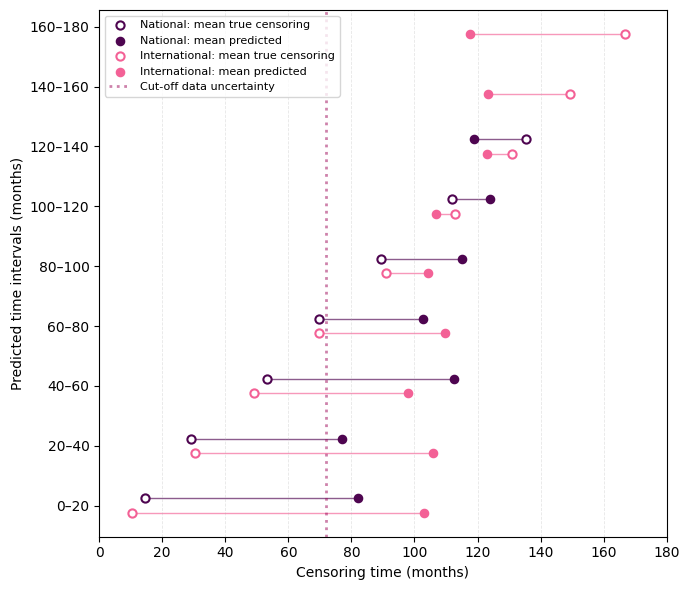

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_censored = pd.DataFrame({'censoring_time': event_times[event_observed == 0], 'predicted': predicted_aggr[event_observed == 0]})
df_censored['censoring_bins'] = pd.cut(df_censored['censoring_time'], bins=np.linspace(0, 180, 10))
df_censored, bins_censored_nat = merge_small_bins(df_censored, 'censoring_bins', min_cases=5, value_column='censoring_time')
summary_nat = (df_censored.groupby('censoring_bins', observed=True).agg(censoring_time=('censoring_time', 'mean'), predicted=('predicted', 'mean'), participants=('predicted', 'size')).reset_index())

df_censored_intl = pd.DataFrame({'censoring_time': event_times_intl[event_observed_intl == 0], 'predicted': predicted_aggr_intl[event_observed_intl == 0]})
df_censored_intl['censoring_bins'] = pd.cut(df_censored_intl['censoring_time'], bins=np.linspace(0, 180, 10))
df_censored_intl, bins_censored_intl = merge_small_bins(df_censored_intl, 'censoring_bins', min_cases=5, value_column='censoring_time')
summary_intl = (df_censored_intl.groupby('censoring_bins', observed=True).agg(censoring_time=('censoring_time', 'mean'), predicted=('predicted', 'mean'), participants=('predicted', 'size')).reset_index())

summary_nat['label'] = summary_nat['censoring_bins'].apply(lambda interval: f'{interval.left:.0f}–{interval.right:.0f}')
summary_intl['label'] = summary_intl['censoring_bins'].apply(lambda interval: f'{interval.left:.0f}–{interval.right:.0f}')

fig, ax = plt.subplots(figsize=(7.0, 6.0))
y_nat = np.arange(len(summary_nat)) + 0.12
y_intl = np.arange(len(summary_intl)) - 0.12
for y, censoring, predicted in zip(y_nat, summary_nat['censoring_time'], summary_nat['predicted']):
    ax.plot([censoring, predicted], [y, y], color='xkcd:plum purple', linewidth=1.0, alpha=0.65, zorder=1)
ax.scatter(summary_nat['censoring_time'], y_nat, color='white', edgecolor='xkcd:plum purple', s=35, linewidth=1.5, label='National: mean true censoring', zorder=3)
ax.scatter(summary_nat['predicted'], y_nat, color='xkcd:plum purple', s=35, label='National: mean predicted', zorder=3)
for y, censoring, predicted in zip(y_intl, summary_intl['censoring_time'], summary_intl['predicted']):
    ax.plot([censoring, predicted], [y, y], color='xkcd:medium pink', linewidth=1.0, alpha=0.65, zorder=1)
ax.scatter(summary_intl['censoring_time'], y_intl, color='white', edgecolor='xkcd:medium pink', s=35, linewidth=1.5, label='International: mean true censoring', zorder=3)
ax.scatter(summary_intl['predicted'], y_intl, color='xkcd:medium pink', s=35, label='International: mean predicted', zorder=3)

ax.axvline(72, color='xkcd:dark fuchsia', linestyle='dotted', linewidth=2.0, alpha=0.5, label='Cut-off data uncertainty')
max_rows = max(len(summary_nat), len(summary_intl))
if len(summary_nat) >= len(summary_intl):
    y_labels = summary_nat['label']
else:
    y_labels = summary_intl['label']

ax.set_yticks(np.arange(max_rows))
ax.set_yticklabels(y_labels)
ax.set_xlim(0, 180)
ax.set_xlabel('Censoring time (months)')
ax.set_ylabel('Predicted time intervals (months)')
ax.legend(loc='best', fontsize=8, frameon=True)
ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/censored_predicted_vs_observed_dumbbell.pdf', bbox_inches='tight')
plt.show()

In [73]:
from sksurv.metrics import (
    as_concordance_index_ipcw_scorer,
    as_cumulative_dynamic_auc_scorer,
    as_integrated_brier_score_scorer,
)
from sksurv import metrics as sksurvmetrics
import numpy as np
import pandas as pd

def bootstrap_auc_ci(survival_train, survival_test, risk_score, times, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    bootstrap_aucs = []
    for _ in range(n_bootstrap):
        indices = rng.choice(len(survival_test), size=len(survival_test), replace=True)
        try:
            auc_bootstrap, _ = sksurvmetrics.cumulative_dynamic_auc(survival_train, survival_test[indices], np.asarray(risk_score)[indices], times)
            if np.all(np.isfinite(auc_bootstrap)):
                bootstrap_aucs.append(auc_bootstrap)
        except (ValueError, ZeroDivisionError, IndexError):
            continue
    bootstrap_aucs = np.asarray(bootstrap_aucs)
    if len(bootstrap_aucs) == 0:
        raise RuntimeError('No valid bootstrap samples were obtained.')
    print(f"Valid bootstrap samples: {len(bootstrap_aucs)}/{n_bootstrap}")
    auc_lower = np.percentile(bootstrap_aucs, 2.5, axis=0)
    auc_upper = np.percentile(bootstrap_aucs, 97.5, axis=0)
    return auc_lower, auc_upper
event_observed_train = (train['esrd_upper'] == train['esrd_lower']).astype(bool).to_numpy()
event_observed_test = (test['esrd_upper'] == test['esrd_lower']).astype(bool).to_numpy()
event_observed_intl = (test_intl['esrd_upper'] == test_intl['esrd_lower']).astype(bool).to_numpy()
survival_train = np.array(list(zip(event_observed_train, train['esrd_lower'])), dtype=[('event', '?'), ('time', '<f8')])
survival_test = np.array(list(zip(event_observed_test, test['esrd_lower'])), dtype=[('event', '?'), ('time', '<f8')])
survival_intl = np.array(list(zip(event_observed_intl, test_intl['esrd_lower'])), dtype=[('event', '?'), ('time', '<f8')])
auc_times = np.linspace(10, 120, 6)
auc_nat, mean_auc_nat = sksurvmetrics.cumulative_dynamic_auc(survival_train, survival_test, -predicted_aggr, auc_times)
auc_intl, mean_auc_intl = sksurvmetrics.cumulative_dynamic_auc(survival_train, survival_intl, -predicted_aggr_intl, auc_times)
auc_nat_lower, auc_nat_upper = bootstrap_auc_ci(survival_train, survival_test, -predicted_aggr, auc_times, n_bootstrap=1000, random_state=1)
auc_intl_lower, auc_intl_upper = bootstrap_auc_ci(survival_train, survival_intl, -predicted_aggr_intl, auc_times, n_bootstrap=1000, random_state=1)
auc_table = pd.DataFrame({'Time, months': auc_times,
                          'National validation': [f'{auc:.3f} ({lower:.3f}–{upper:.3f})' for auc, lower, upper in zip(auc_nat, auc_nat_lower, auc_nat_upper)],
                          'International validation': [f'{auc:.3f} ({lower:.3f}–{upper:.3f})' for auc, lower, upper in zip(auc_intl, auc_intl_lower, auc_intl_upper)]})
auc_table['Time, months'] = auc_table['Time, months'].round(1)
print('\nTime-dependent AUC with pointwise 95% bootstrap confidence intervals\n')
print(auc_table.to_string(index=False))
print(f'\nMean AUC national validation: {mean_auc_nat:.3f}')
print(f'Mean AUC international validation: {mean_auc_intl:.3f}')
auc_table.to_csv('raw_results/time_dependent_auc_with_95ci.csv', index=False)

Valid bootstrap samples: 1000/1000
Valid bootstrap samples: 1000/1000

Time-dependent AUC with pointwise 95% bootstrap confidence intervals

 Time, months National validation International validation
         10.0 0.928 (0.893–0.957)      0.955 (0.905–0.986)
         32.0 0.892 (0.850–0.930)      0.929 (0.886–0.970)
         54.0 0.865 (0.812–0.913)      0.897 (0.851–0.938)
         76.0 0.885 (0.827–0.938)      0.887 (0.837–0.934)
         98.0 0.881 (0.806–0.947)      0.885 (0.821–0.941)
        120.0 0.828 (0.653–0.985)      0.909 (0.851–0.960)

Mean AUC national validation: 0.878
Mean AUC international validation: 0.908


In [74]:
egfr_col = "Epi1"  # replace with your baseline eGFR column name

train["kidney_failure_event"] = (train["esrd_lower"] == train["esrd_upper"]).astype(int)

train["ckd_g_category"] = pd.cut(
    pd.to_numeric(train[egfr_col], errors="coerce"),
    bins=[-np.inf, 15, 30, 45, 60],
    labels=["G5", "G4", "G3b", "G3a"],
    right=False
)

ckd_stage_summary = (
    train.groupby("ckd_g_category", observed=False)
    .agg(
        participants=("kidney_failure_event", "size"),
        kidney_failure_cases=("kidney_failure_event", "sum")
    )
    .reset_index()
)

ckd_stage_summary["percentage_of_cohort"] = 100 * ckd_stage_summary["participants"] / train[egfr_col].notna().sum()
ckd_stage_summary["kidney_failure_percentage"] = 100 * ckd_stage_summary["kidney_failure_cases"] / ckd_stage_summary["participants"]

ckd_stage_summary["percentage_of_cohort"] = ckd_stage_summary["percentage_of_cohort"].round(1)
ckd_stage_summary["kidney_failure_percentage"] = ckd_stage_summary["kidney_failure_percentage"].round(1)
ckd_stage_summary.to_csv('raw_results/ckd_category_training.csv', index=False)
ckd_stage_summary

,ckd_g_category,participants,kidney_failure_cases,percentage_of_cohort,kidney_failure_percentage
0,G5,361,254,10.0,70.4
1,G4,1237,338,34.4,27.3
2,G3b,1290,101,35.8,7.8
3,G3a,711,35,19.8,4.9


In [75]:
egfr_col = 'EGFR'

test['kidney_failure_event'] = (test['esrd_lower'] == test['esrd_upper']).astype(int)
test["ckd_g_category"] = pd.cut(pd.to_numeric(test[egfr_col], errors="coerce"), bins=[-np.inf, 15, 30, 45, 60], labels=["G5", "G4", "G3b", "G3a"], right=False)
ckd_stage_summary = (test.groupby("ckd_g_category", observed=False).agg(participants=("kidney_failure_event", "size"), kidney_failure_cases=("kidney_failure_event", "sum")).reset_index())
ckd_stage_summary["percentage_of_cohort"] = 100 * ckd_stage_summary["participants"] / test[egfr_col].notna().sum()
ckd_stage_summary["percentage_of_cohort"] = ckd_stage_summary["percentage_of_cohort"].round(1)
ckd_stage_summary

,ckd_g_category,participants,kidney_failure_cases,percentage_of_cohort
0,G5,56,44,16.2
1,G4,102,52,29.5
2,G3b,117,26,33.8
3,G3a,71,7,20.5


In [79]:
egfr_col = "EGFR"

test_intl["kidney_failure_event"] = (test_intl["esrd_lower"] == test_intl["esrd_upper"]).astype(int)

test_intl["ckd_g_category"] = pd.cut(
    pd.to_numeric(test_intl[egfr_col], errors="coerce"),
    bins=[-np.inf, 15, 30, 45, 60, 90, np.inf],
    labels=["G5", "G4", "G3b", "G3a", "G2", "G1"],
    right=False
)

ckd_stage_summary = (
    test_intl.groupby("ckd_g_category", observed=False)
    .agg(
        participants=("kidney_failure_event", "size"),
        kidney_failure_cases=("kidney_failure_event", "sum")
    )
    .reset_index()
)

ckd_stage_summary["percentage_of_cohort"] = 100 * ckd_stage_summary["participants"] / test_intl[egfr_col].notna().sum()
ckd_stage_summary["percentage_of_cohort"] = ckd_stage_summary["percentage_of_cohort"].round(1)
ckd_stage_summary

,ckd_g_category,participants,kidney_failure_cases,percentage_of_cohort
0,G5,42,40,14.1
1,G4,85,52,28.6
2,G3b,48,15,16.2
3,G3a,33,3,11.1
4,G2,58,4,19.5
5,G1,31,0,10.4


In [78]:
test_intl['ckd_g_category']

0      G3b
1      G3a
2       G4
3      G3b
4       G4
      ... 
362    NaN
363    NaN
364    NaN
366    NaN
367    NaN
Name: ckd_g_category, Length: 297, dtype: category
Categories (6, object): ['G5' < 'G4' < 'G3b' < 'G3a' < 'G2' < 'G1']

In [20]:
def baseline_table(features, data_frame): 
    summaries = [] 
    for feat in features: 
        description = data_frame[feat].describe() 
        summary = ( 
            f"{description['mean']:.1f} ± {description['std']:.1f}; " 
            f"{description['50%']:.1f} " 
            f"[{description['25%']:.1f}–{description['75%']:.1f}]"
        ) 
        summaries.append(summary)
    return pd.DataFrame({"Summary": summaries}, index=features)

In [21]:
features = ['EGFR', 'URIN_PROT', 'BMI', 'AGE', 'PHOSPHORUS', 'CALCIUM', 'HB', 'CHOLESTEROL']
baseline_table(features = features, data_frame = test)

,Summary
EGFR,31.7 ± 14.4; 31.8 [18.7–42.9]
URIN_PROT,1.3 ± 1.6; 0.7 [0.2–1.9]
BMI,26.7 ± 5.2; 26.2 [23.7–29.0]
AGE,58.1 ± 16.2; 61.6 [47.6–69.4]
PHOSPHORUS,3.9 ± 0.8; 3.8 [3.4–4.3]
CALCIUM,9.6 ± 0.6; 9.6 [9.3–9.9]
HB,12.7 ± 1.9; 12.7 [11.3–14.1]
CHOLESTEROL,207.7 ± 47.5; 204.0 [174.2–232.0]


In [22]:
features = ['EGFR', 'URIN_PROT', 'BMI', 'AGE', 'PHOSPHORUS', 'CALCIUM', 'HB', 'CHOLESTEROL']
baseline_table(features = features, data_frame = test_intl)

,Summary
EGFR,45.5 ± 30.5; 35.3 [21.3–64.3]
URIN_PROT,1.0 ± 1.4; 0.5 [0.2–1.3]
BMI,27.1 ± 5.1; 26.4 [23.6–30.3]
AGE,55.6 ± 15.5; 57.0 [47.0–68.0]
PHOSPHORUS,3.5 ± 0.8; 3.4 [3.0–3.8]
CALCIUM,9.3 ± 0.5; 9.3 [9.0–9.6]
HB,13.2 ± 1.8; 13.1 [11.8–14.3]
CHOLESTEROL,186.0 ± 48.4; 181.4 [150.5–212.3]


In [85]:
train.rename(columns={'Epi1': 'EGFR', 
                      'Prot1': 'URIN_PROT', 
                      'BMI1': 'BMI', 
                      'Eta1': 'AGE', 
                      'P1': 'PHOSPHORUS', 
                      'Ca1': 'CALCIUM', 
                      'Hb1': 'HB', 
                      'Colesterolo1': 'CHOLESTEROL'}, inplace=True)
features = ['EGFR', 'URIN_PROT', 'BMI', 'AGE', 'PHOSPHORUS', 'CALCIUM', 'HB', 'CHOLESTEROL']
baseline_table(features = features, data_frame = train)

,Summary
EGFR,32.5 ± 13.0; 32.3 [22.0–42.4]
URIN_PROT,1.1 ± 1.8; 0.4 [0.1–1.2]
BMI,27.7 ± 4.8; 27.2 [24.5–30.1]
AGE,67.4 ± 13.0; 70.1 [60.6–76.6]
PHOSPHORUS,3.8 ± 0.8; 3.7 [3.3–4.1]
CALCIUM,9.3 ± 0.6; 9.3 [9.0–9.7]
HB,12.5 ± 1.8; 12.5 [11.4–13.8]
CHOLESTEROL,195.0 ± 42.7; 193.7 [168.0–218.0]
